# Semanas 3 e 4: Controle de Qualidade, Detecção de Anomalias e Avaliação de Busca

* **Recuperação de Dados Persistidos:** Carregamento dos embeddings, textos e metadados diretamente da base vetorial local.
* **Avaliação Heurística de Qualidade:** Identificação de chunks com potenciais problemas de formatação, ruídos de extração de PDF ou tamanho inadequado.
* **Detecção de Anomalias Não Supervisionada:** Aplicação de algoritmos de Machine Learning (`IsolationForest`) no espaço vetorial para identificar pontos fora do padrão temático.
* **Mecanismo de Busca Semântica com Score de Similaridade:** Implementação de busca com métricas de distância/similaridade de cosseno.

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ajuste do path para importar módulos de src/
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from sklearn.ensemble import IsolationForest
except ImportError:
    from sklearn.ensemble._iforest import IsolationForest

from src.storage.vector_store import LocalVectorStore
from src.embeddings.model import EmbeddingService

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Extração dos Embeddings e Metadados do ChromaDB

* **O que é feito:** Leitura de todos os 1.144 chunks, vetores e metadados persistidos no ChromaDB.
* **Como é feito:** O método `get(include=['embeddings', 'documents', 'metadatas'])` extrai os tensores sem necessidade de reprocessar os arquivos brutos.
* **Por que:** Garante desacoplamento entre a etapa de ingestão e a etapa de modelagem/avaliação, otimizando tempo computacional.

In [9]:
db = LocalVectorStore(
    persist_directory=str(root_dir / "chroma_db"),
    collection_name="knowledge_base"
)

# Recupera todos os dados salvos
data = db.collection.get(include=["embeddings", "documents", "metadatas"])

ids = data["ids"]
documents = data["documents"]
metadatas = data["metadatas"]
embeddings = np.array(data["embeddings"])

print(f"Total de registros recuperados: {len(ids)}")
print(f"Formato da matriz de embeddings: {embeddings.shape}")

# Montagem de um DataFrame analítico
df_corpus = pd.DataFrame({
    "id": ids,
    "source": [m["source"] for m in metadatas],
    "file_type": [m["file_type"] for m in metadatas],
    "chunk_index": [m["chunk_index"] for m in metadatas],
    "text": documents,
    "char_count": [len(doc) for doc in documents],
    "word_count": [len(doc.split()) for doc in documents]
})

df_corpus.head(3)

Total de registros recuperados: 1144
Formato da matriz de embeddings: (1144, 384)


,id,source,file_type,chunk_index,text,char_count,word_count
0,1984.pdf_chunk_0,1984.pdf,.pdf,0,Project Gutenberg Australia Title: Nineteen ei...,1808,300
1,1984.pdf_chunk_1,1984.pdf,.pdf,1,"simply an enormous face, more than a metre wid...",1685,300
2,1984.pdf_chunk_2,1984.pdf,.pdf,2,"of the party. His hair was very fair, his face...",1781,300


## Controle de Qualidade Heurístico

* **O que é feito:** Análise de integridade textual e métricas superficiais dos chunks (contagem de palavras e densidade de caracteres).
* **Como é feito:** Inspeção de outliers de comprimento (blocos com pouquíssimas palavras decorrentes de finais de capítulo ou ruídos de PDF).
* **Por que:** Documentos com pouco conteúdo semântico geram ruído na base de conhecimento e prejudicam a precisão das buscas.

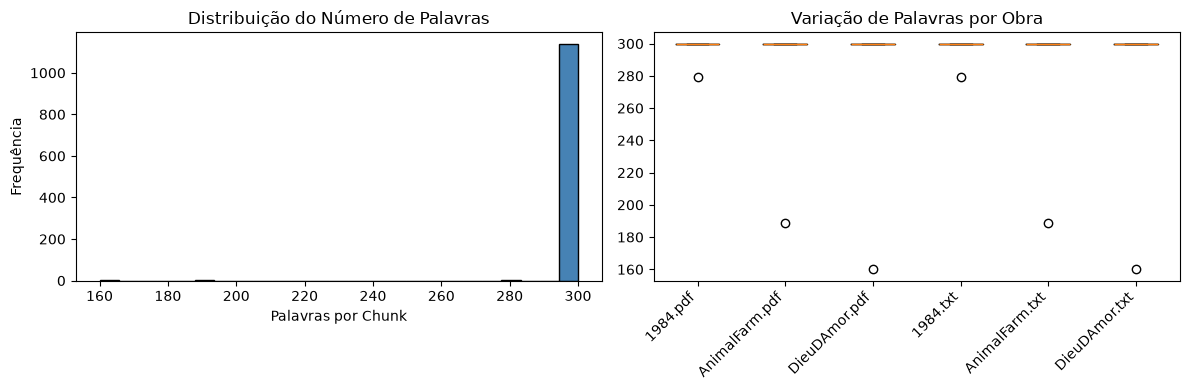

Blocos com menos de 40 palavras identificados: 0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de palavras
axes[0].hist(df_corpus["word_count"], bins=25, color="steelblue", edgecolor="black")
axes[0].set_title("Distribuição do Número de Palavras")
axes[0].set_xlabel("Palavras por Chunk")
axes[0].set_ylabel("Frequência")

# Boxplot por obra/fonte
sources = df_corpus["source"].unique()
word_data_by_source = [df_corpus[df_corpus["source"] == s]["word_count"] for s in sources]
try:
    axes[1].boxplot(word_data_by_source, tick_labels=sources)
except TypeError:
    axes[1].boxplot(word_data_by_source, labels=sources)
axes[1].set_title("Variação de Palavras por Obra")
axes[1].set_xticklabels(sources, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Identificando blocos suspeitos de ruído (ex: menos de 40 palavras)
suspects = df_corpus[df_corpus["word_count"] < 40]
print(f"Blocos com menos de 40 palavras identificados: {len(suspects)}")
if len(suspects) > 0:
    print("\nExemplo de bloco curto identificado:")
    print(suspects.iloc[0]["text"])

## Detecção de Anomalias no Espaço de Embeddings

* **O que é feito:** Aplicação de Aprendizado Não Supervisionado para identificar chunks que representam outliers estatísticos na distribuição semântica global.
* **Como é feito:** Utiliza-se o algoritmo **Isolation Forest** (`sklearn.ensemble.IsolationForest`) alimentado diretamente pela matriz de 384 dimensões dos embeddings.
* **Por que:** Permite ao sistema detectar automaticamente trechos fora do padrão do corpus (ex: licenças de domínio público, cabeçalhos editoriais, índices repetitivos ou textos fora de tema).

In [11]:
# Contaminação estimada em 3% a 5% (fração esperada de ruídos/outliers)
contamination_rate = 0.04
iso_forest = IsolationForest(
    n_estimators=150,
    contamination=contamination_rate,
    random_state=42
)

# Predição: 1 para normal, -1 para anomalia
preds = iso_forest.fit_predict(embeddings)
anomaly_scores = iso_forest.decision_function(embeddings)

df_corpus["is_anomaly"] = preds == -1
df_corpus["anomaly_score"] = anomaly_scores

n_anomalies = df_corpus["is_anomaly"].sum()
print(f"Total de anomalias semânticas detectadas: {n_anomalies} ({n_anomalies / len(df_corpus) * 100:.2f}%)")

Total de anomalias semânticas detectadas: 46 (4.02%)


## Análise Qualitativa dos Chunks Anômalos

* **O que é feito:** Extração e leitura dos chunks classificados com as menores pontuações de decisão semântica.
* **Como é feito:** Ordenação pelo `anomaly_score` ascendente.
* **Por que:** Valida se o algoritmo de isolamento está capturando ruídos estruturais, metadados de catálogo ou quebras narrativas reais.

In [12]:
anomalies_df = df_corpus[df_corpus["is_anomaly"]].sort_values("anomaly_score")

print("--- TOP 3 CHUNKS IDENTIFICADOS COMO ANOMALIAS SEMÂNTICAS ---\n")
for idx, row in anomalies_df.head(3).iterrows():
    print(f"Arquivo: {row['source']} | Chk Index: {row['chunk_index']} | Score: {row['anomaly_score']:.4f}")
    print(f"Texto: {row['text'][:280]}...\n")

--- TOP 3 CHUNKS IDENTIFICADOS COMO ANOMALIAS SEMÂNTICAS ---

Arquivo: 1984.pdf | Chk Index: 220 | Score: -0.0453
Texto: You look normal and innocent. If you keep clear of people like me, you might stay alive for another fifty years.' 'No. I've thought it all out. What you do, I'm going to do. And don't be too downhearted. I'm rather good at staying alive.' 'We may be together for another six month...

Arquivo: 1984.txt | Chk Index: 220 | Score: -0.0453
Texto: You look normal and innocent. If you keep clear of people like me, you might stay alive for another fifty years.' 'No. I've thought it all out. What you do, I'm going to do. And don't be too downhearted. I'm rather good at staying alive.' 'We may be together for another six month...

Arquivo: 1984.txt | Chk Index: 245 | Score: -0.0180
Texto: could be and indeed was foreseen before the middle of the twentieth century. With the absorption of Europe by Russia and of the British Empire by the United States, two of the three existing 

## Avaliação do Mecanismo de Busca Semântica

* **O que é feito:** Execução de consultas com extração de distâncias matemáticas (distância L2 ou cosseno) do ChromaDB para avaliar a relevância dos documentos recuperados.
* **Como é feito:** O método `db.collection.query` retorna a métrica de `distances`, permitindo analisar se a relevância cai bruscamente entre os primeiros colocados.
* **Por que:** Atende ao requisito de criar uma base pesquisável de alta fidelidade semântica com ranking de proximidade[cite: 1].

In [13]:
embedder = EmbeddingService()

def semantic_search_evaluated(query: str, top_k: int = 5):
    query_vec = embedder.generate_embeddings([query])[0].tolist()
    
    # Query trazendo distances
    res = db.collection.query(
        query_embeddings=[query_vec],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    
    docs = res["documents"][0]
    metas = res["metadatas"][0]
    dists = res["distances"][0]
    
    print(f"RESULTADOS PARA A CONSULTA: '{query}'\n")
    for rank, (d, m, dist) in enumerate(zip(docs, metas, dists), start=1):
        print(f"Rank {rank} | Distância: {dist:.4f} | Fonte: {m['source']}")
        print(f"Trecho: {d[:200]}...\n")

# Teste com uma temática conceitual
semantic_search_evaluated("psychological manipulation and government surveillance", top_k=4)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

RESULTADOS PARA A CONSULTA: 'psychological manipulation and government surveillance'

Rank 1 | Distância: 1.2227 | Fonte: 1984.pdf
Trecho: crime at some time in the future. A Party member is required to have not only the right opinions, but the right instincts. Many of the beliefs and attitudes demanded of him are never plainly stated, a...

Rank 2 | Distância: 1.2227 | Fonte: 1984.txt
Trecho: crime at some time in the future. A Party member is required to have not only the right opinions, but the right instincts. Many of the beliefs and attitudes demanded of him are never plainly stated, a...

Rank 3 | Distância: 1.2272 | Fonte: 1984.pdf
Trecho: TO SECURE THESE RIGHTS, GOVERNMENTS ARE INSTITUTED AMONG MEN, DERIVING THEIR POWERS FROM THE CONSENT OF THE GOVERNED. THAT WHENEVER ANY FORM OF GOVERNMENT BECOMES DESTRUCTIVE OF THOSE ENDS, IT IS THE ...

Rank 4 | Distância: 1.2272 | Fonte: 1984.txt
Trecho: TO SECURE THESE RIGHTS, GOVERNMENTS ARE INSTITUTED AMONG MEN, DERIVING THEIR POWERS FRO